In [1]:
import pandas as pd

data = {
    "Review": [
        "The food was delicious and delivery was quick.",
        "Very poor service and cold food.",
        "Excellent taste and friendly staff.",
        "The order arrived late and packaging was damaged.",
        "Amazing food quality and fast delivery.",
        "Customer service was terrible.",
        "Loved the taste and presentation.",
        "Food was not fresh and delivery took too long.",
        "Great experience and good value for money.",
        "The restaurant ignored my complaint."
    ]
}

df = pd.DataFrame(data)

df.head()

,Review
0,The food was delicious and delivery was quick.
1,Very poor service and cold food.
2,Excellent taste and friendly staff.
3,The order arrived late and packaging was damaged.
4,Amazing food quality and fast delivery.


In [2]:
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [3]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

In [4]:
df['Clean_Review'] = df['Review'].apply(clean_text)

df.head()

,Review,Clean_Review
0,The food was delicious and delivery was quick.,food delicious delivery quick
1,Very poor service and cold food.,poor service cold food
2,Excellent taste and friendly staff.,excellent taste friendly staff
3,The order arrived late and packaging was damaged.,order arrived late packaging damaged
4,Amazing food quality and fast delivery.,amazing food quality fast delivery


In [5]:
from textblob import TextBlob

In [6]:
def classify_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

In [7]:
df['Sentiment'] = df['Review'].apply(classify_sentiment)

df[['Review','Sentiment']]

,Review,Sentiment
0,The food was delicious and delivery was quick.,Positive
1,Very poor service and cold food.,Negative
2,Excellent taste and friendly staff.,Positive
3,The order arrived late and packaging was damaged.,Negative
4,Amazing food quality and fast delivery.,Positive
5,Customer service was terrible.,Negative
6,Loved the taste and presentation.,Positive
7,Food was not fresh and delivery took too long.,Negative
8,Great experience and good value for money.,Positive
9,The restaurant ignored my complaint.,Negative


In [8]:
print(df['Sentiment'].value_counts())

Sentiment
Positive    5
Negative    5
Name: count, dtype: int64


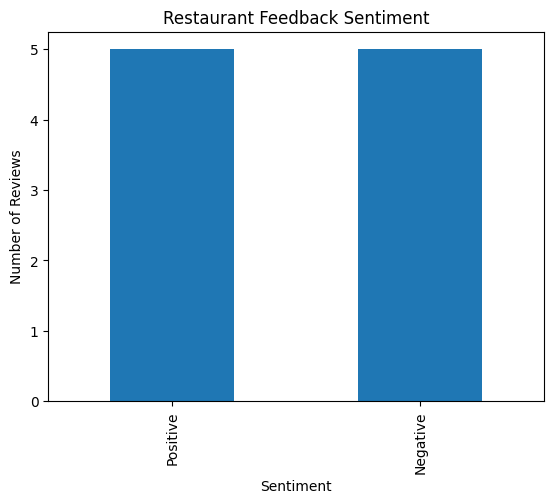

In [9]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Restaurant Feedback Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [10]:
from collections import Counter

all_words = " ".join(df['Clean_Review'])

word_freq = Counter(all_words.split())

print(word_freq.most_common(15))

[('food', 4), ('delivery', 3), ('service', 2), ('taste', 2), ('delicious', 1), ('quick', 1), ('poor', 1), ('cold', 1), ('excellent', 1), ('friendly', 1), ('staff', 1), ('order', 1), ('arrived', 1), ('late', 1), ('packaging', 1)]


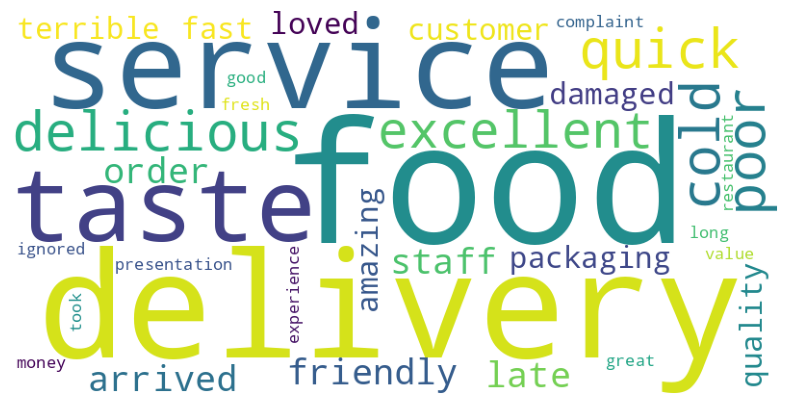

In [11]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [12]:
negative_reviews = df[df['Sentiment']=="Negative"]

negative_reviews

,Review,Clean_Review,Sentiment
1,Very poor service and cold food.,poor service cold food,Negative
3,The order arrived late and packaging was damaged.,order arrived late packaging damaged,Negative
5,Customer service was terrible.,customer service terrible,Negative
7,Food was not fresh and delivery took too long.,food fresh delivery took long,Negative
9,The restaurant ignored my complaint.,restaurant ignored complaint,Negative


In [13]:
print(df['Sentiment'].value_counts())

Sentiment
Positive    5
Negative    5
Name: count, dtype: int64


In [14]:
print("\nRestaurant Feedback Insights")
print("--------------------------------")

positive_count = len(df[df['Sentiment'] == 'Positive'])
negative_count = len(df[df['Sentiment'] == 'Negative'])

print("Total Positive Reviews :", positive_count)
print("Total Negative Reviews :", negative_count)

print("\nCommon Positive Areas:")
print("- Delicious food")
print("- Good taste and presentation")
print("- Fast delivery")
print("- Friendly staff")
print("- Value for money")

print("\nCommon Customer Complaints:")
print("- Delayed delivery")
print("- Cold food")
print("- Poor customer service")
print("- Damaged packaging")
print("- Ignored customer complaints")

print("\nRecommendations:")
print("- Improve delivery speed")
print("- Enhance food packaging quality")
print("- Train customer support staff")
print("- Ensure food freshness before dispatch")
print("- Respond quickly to customer complaints")


Restaurant Feedback Insights
--------------------------------
Total Positive Reviews : 5
Total Negative Reviews : 5

Common Positive Areas:
- Delicious food
- Good taste and presentation
- Fast delivery
- Friendly staff
- Value for money

Common Customer Complaints:
- Delayed delivery
- Cold food
- Poor customer service
- Damaged packaging
- Ignored customer complaints

Recommendations:
- Improve delivery speed
- Enhance food packaging quality
- Train customer support staff
- Ensure food freshness before dispatch
- Respond quickly to customer complaints
